<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
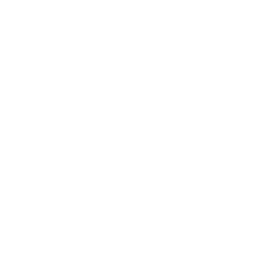
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clinical Trial Adverse Event Coding</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Drug Safety Surveillance &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Adverse event datasets arrive with verbatim MedDRA preferred terms, but
regulatory safety tables are organized by System Organ Class (SOC). This
example builds a PROC FORMAT value format that maps each of 12 preferred
terms to its SOC, then uses that single format to drive every downstream
tabulation: a PROC FREQ cross-tabulation of SOC by treatment arm, a SOC by
severity breakdown, and a serious-AE summary across 5,000 adverse-event
records. Because the format is the only place the mapping lives, re-coding
the trial to a new MedDRA version is a one-format edit rather than a
rewrite of every report. ODS OUTPUT captures the SOC frequencies as a
dataset for downstream signal review.

The 12 verbatim terms collapse cleanly into 7 System Organ Classes.
**Gastrointestinal disorders** dominates the safety profile at 1,655 of
5,000 events (it pools four preferred terms), roughly twice the next
class. The coding also surfaces a built-in clinical rule: the two
neutropenia terms are never graded mild, so **Blood and lymphatic
disorders** carries zero mild events. All 5,000 records resolve to a
treatment arm, and 982 events (19.6%) are flagged serious.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------:|
| WORK.AE_RAW | Synthetic adverse event records with MedDRA preferred terms | 5,000 |
| WORK.RANDOMIZATION | Subject treatment arm assignments | 800 |

The scenario simulates an oncology trial: 5,000 adverse events drawn from
a 12-term MedDRA panel, recorded against 800 randomized subjects across
three treatment arms (investigational, active comparator, placebo). The
12 verbatim preferred terms are deliberately spread across the safety
spectrum so the SOC format has to pool several terms into one class.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic adverse event dataset
   MedDRA preferred terms mapped to SOC categories
   -------------------------------------------------------- */
data work.ae_raw;
    call streaminit(42);
    array pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    array pt_names[12] $30 _temporary_ ('Nausea' 'Headache' 'Vomiting' 'Diarrhoea' 'Cough' 'Fatigue' 'Arthralgia' 'Pyrexia' 'Abdominal pain' 'Neutropenia' 'Febrile neutropenia' 'Infusion related reaction');
    array sev_list[3] $10 _temporary_ ('MILD' 'MODERATE' 'SEVERE');
    do i = 1 to 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', put(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        aedecod = pt_names[pt_idx];
        sev_idx = int(rand('uniform') * 3) + 1;
        if pt_idx in (10, 11) then sev_idx = max(sev_idx, 2);
        aesev = sev_list[sev_idx];
        aeser = ifc(aesev = 'SEVERE' and rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        if aestdy > 365 then aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', put(int(rand('uniform') * 25) + 1, z3.));
        output;
    end;
    drop i pt_idx sev_idx;
run;

NOTE: DATA work.ae_raw


NOTE: Wrote work.ae_raw (5000 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.38 seconds
  cpu   0.38 seconds


In [2]:
/* --------------------------------------------------------
   Generate subject randomization table
   -------------------------------------------------------- */
data work.randomization;
    call streaminit(43);
    array arms[3] $20 _temporary_ ('INVESTIGATIONAL' 'ACTIVE_COMPARATOR' 'PLACEBO');
    do subject_id = 1 to 800;
        usubjid = cat('ONC-2025-', put(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arms[arm_idx];
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        output;
    end;
    drop arm_idx;
    format randomization_date date9.;
run;

NOTE: DATA work.randomization


NOTE: Wrote work.randomization (800 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                        Raw Preferred Term Frequency (Unmapped)                                         

                                                   The FREQ Procedure

aedecod                      Frequency    Percent
--------------------------------------------------
Febrile neutropenia                464      9.28
Fatigue                            433      8.66
Abdominal pain                     432      8.64
Neutropenia                        429      8.58
Vomiting                           419      8.38
Arthralgia                         414      8.28
Nausea                             409      8.18
Headache                           405      8.10
Infusion related reaction          405      8.10
Cough                              403      8.06
Diarrhoea                          395      7.90
Pyrexia                            392      7.84


NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


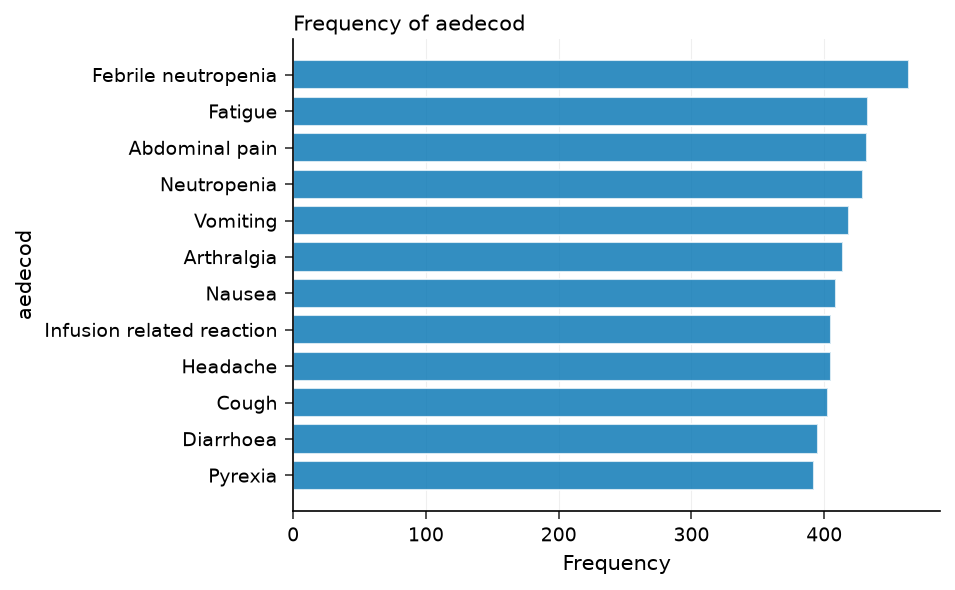

In [3]:
/* --------------------------------------------------------
   Baseline preferred term frequency before SOC mapping
   -------------------------------------------------------- */
proc freq data=work.ae_raw order=freq;
    tables aedecod / nocum;
    title 'Raw Preferred Term Frequency (Unmapped)';
run;

---

                                        Raw Preferred Term Frequency (Unmapped)                                         



NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


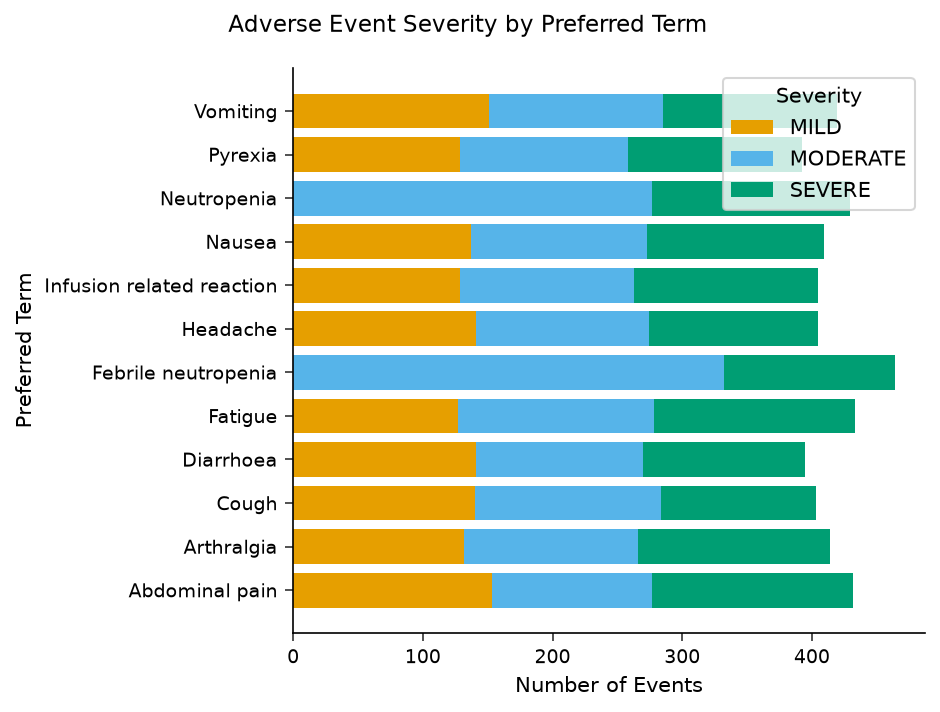

In [4]:
/* --------------------------------------------------------
   AE severity composition by preferred term. HBAR places the
   long verbatim term names on the vertical axis where they
   stay readable, with severity stacked within each bar.
   -------------------------------------------------------- */
proc sgplot data=work.ae_raw;
    hbar aedecod / group=aesev groupdisplay=stack;
    yaxis label='Preferred Term';
    xaxis label='Number of Events';
    keylegend / title='Severity';
    title 'Adverse Event Severity by Preferred Term';
run;

---

In [5]:
/* --------------------------------------------------------
   Define the MedDRA preferred term -> System Organ Class
   value format. The format is keyed on the preferred-term
   text so a single PUT() call codes any AE record to its SOC.
   -------------------------------------------------------- */
proc format;
    value $pt_to_soc
        'Nausea'                    = 'Gastrointestinal disorders'
        'Vomiting'                  = 'Gastrointestinal disorders'
        'Diarrhoea'                 = 'Gastrointestinal disorders'
        'Abdominal pain'            = 'Gastrointestinal disorders'
        'Headache'                  = 'Nervous system disorders'
        'Fatigue'                   = 'General disorders'
        'Pyrexia'                   = 'General disorders'
        'Cough'                     = 'Respiratory disorders'
        'Arthralgia'                = 'Musculoskeletal disorders'
        'Neutropenia'               = 'Blood and lymphatic disorders'
        'Febrile neutropenia'       = 'Blood and lymphatic disorders'
        'Infusion related reaction' = 'Immune system disorders'
        other                       = 'Uncoded'
    ;
    value $sev_rank
        'MILD'     = '1-Mild'
        'MODERATE' = '2-Moderate'
        'SEVERE'   = '3-Severe'
        other      = '9-Unknown'
    ;
    value $serious_fmt
        'Y' = 'Serious'
        'N' = 'Non-Serious'
    ;
run;

NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Merge AE records with treatment arm, then apply the SOC
   format. PUT(aedecod, $pt_to_soc.) is the only mapping step
   needed; severity and seriousness are coded the same way.
   -------------------------------------------------------- */
proc sort data=work.ae_raw; by usubjid; run;
proc sort data=work.randomization; by usubjid; run;

data work.ae_coded;
    merge work.ae_raw (in=a)
          work.randomization (in=b keep=usubjid treatment_arm);
    by usubjid;
    if a;
    soc_class     = put(aedecod, $pt_to_soc.);
    severity_rank = put(aesev,   $sev_rank.);
    serious_flag  = put(aeser,   $serious_fmt.);
run;

NOTE: PROC SORT data=work.ae_raw

NOTE: Read 5000 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (5000 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Read 800 rows from work.randomization.
NOTE: Wrote work.randomization (800 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 5000 rows, max BY-group size: 15 (O(1) memory verified)
NOTE: Stream 2 processed 800 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (5000 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.12 seconds
  cpu   0.12 seconds


In [7]:
/* --------------------------------------------------------
   SOC-level frequency by treatment arm and by severity.
   The two-way text tables carry the counts; PLOTS=NONE
   suppresses the default mosaic so the readable HBAR charts
   below tell the visual story. ODS OUTPUT captures the SOC
   frequencies for signal detection.
   -------------------------------------------------------- */
ods output onewayfreqs=work.soc_freq_table;

proc freq data=work.ae_coded order=freq plots=none;
    tables soc_class * treatment_arm / nocol nopercent;
    tables soc_class * severity_rank / nocol nopercent;
    title 'AE Incidence by System Organ Class and Treatment Arm';
run;

ods output close;

                                  AE Incidence by System Organ Class and Treatment Arm                                  

                                                   The FREQ Procedure

Table of soc_class by treatment_arm

soc_class                     |ACTIVE_COMPARATOR |  INVESTIGATIONAL |          PLACEBO |             Total
------------------------------+------------------+------------------+------------------+------------------
Blood and lymphatic disorders |              277 |              278 |              338 |               893
------------------------------+------------------+------------------+------------------+------------------
Gastrointestinal disorders    |              567 |              514 |              574 |              1655
------------------------------+------------------+------------------+------------------+------------------
General disorders             |              275 |              272 |              278 |               825
---------------------

NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


---

                                  AE Incidence by System Organ Class and Treatment Arm                                  



NOTE: PROC SGPLOT data=work.ae_coded

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


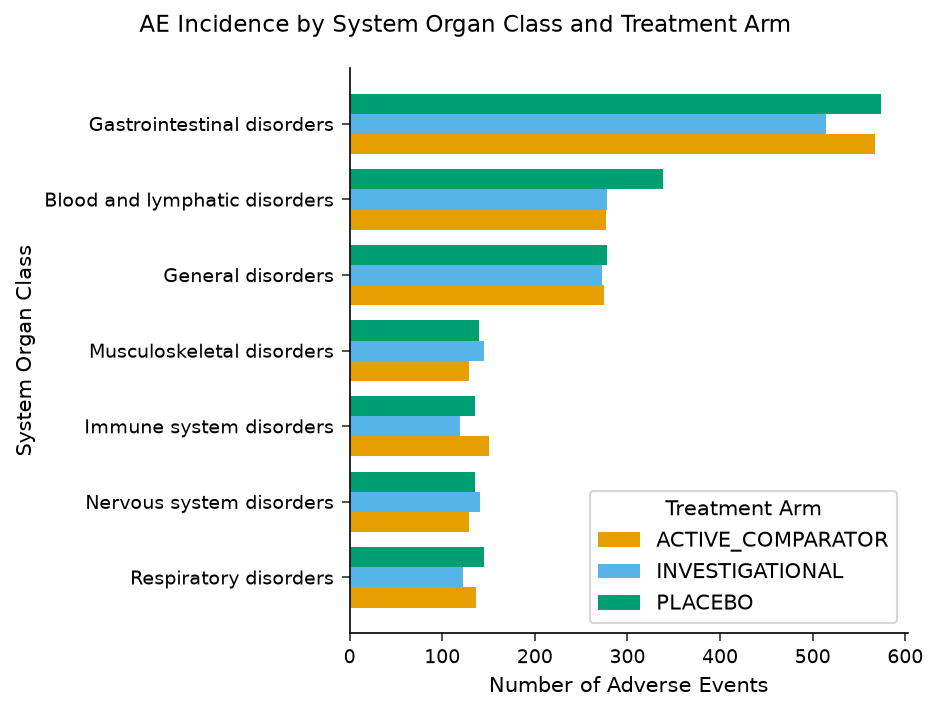

In [8]:
/* --------------------------------------------------------
   Readable view of the SOC x arm table above. Every bar is
   keyed on soc_class, a column that exists only because the
   $pt_to_soc format coded it from the verbatim term.
   -------------------------------------------------------- */
proc sgplot data=work.ae_coded;
    hbar soc_class / group=treatment_arm groupdisplay=cluster
                     categoryorder=respdesc;
    yaxis label='System Organ Class';
    xaxis label='Number of Adverse Events';
    keylegend / title='Treatment Arm';
    title 'AE Incidence by System Organ Class and Treatment Arm';
run;

---

                                  AE Incidence by System Organ Class and Treatment Arm                                  



NOTE: PROC SGPLOT data=work.ae_coded

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


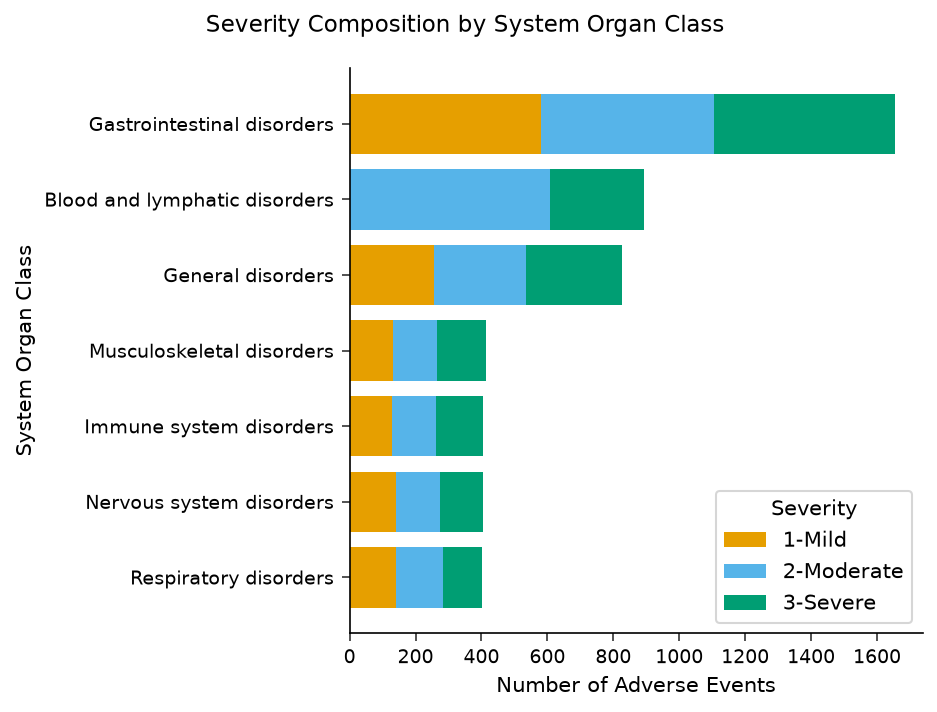

In [9]:
/* --------------------------------------------------------
   Severity composition within each SOC. The absent mild
   segment for Blood and lymphatic disorders is the coded
   neutropenia rule made visible.
   -------------------------------------------------------- */
proc sgplot data=work.ae_coded;
    hbar soc_class / group=severity_rank groupdisplay=stack
                     categoryorder=respdesc;
    yaxis label='System Organ Class';
    xaxis label='Number of Adverse Events';
    keylegend / title='Severity';
    title 'Severity Composition by System Organ Class';
run;

In [10]:
/* --------------------------------------------------------
   Serious AE summary by SOC for the safety narrative.
   PLOTS=NONE keeps the listing clean; the HBAR below renders
   the serious-event profile by SOC and arm.
   -------------------------------------------------------- */
proc freq data=work.ae_coded order=freq plots=none;
    where aeser = 'Y';
    tables soc_class * treatment_arm / nocol nopercent;
    title 'Serious Adverse Events by SOC and Treatment Arm';
run;

                                    Serious Adverse Events by SOC and Treatment Arm                                     

                                                   The FREQ Procedure

Table of soc_class by treatment_arm

soc_class                     |ACTIVE_COMPARATOR |  INVESTIGATIONAL |          PLACEBO |             Total
------------------------------+------------------+------------------+------------------+------------------
Blood and lymphatic disorders |               62 |               43 |               51 |               156
------------------------------+------------------+------------------+------------------+------------------
Gastrointestinal disorders    |              114 |               85 |              126 |               325
------------------------------+------------------+------------------+------------------+------------------
General disorders             |               60 |               57 |               52 |               169
---------------------

NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


---

                                    Serious Adverse Events by SOC and Treatment Arm                                     



NOTE: PROC SGPLOT data=work.ae_coded

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg


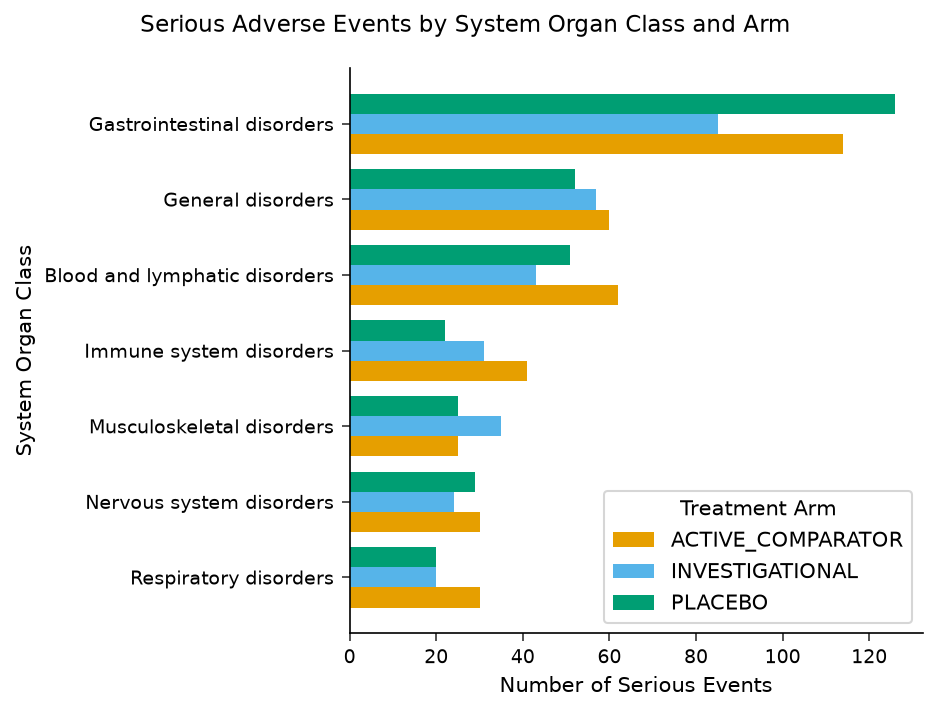

In [11]:
/* --------------------------------------------------------
   Serious-AE profile by SOC and treatment arm.
   -------------------------------------------------------- */
proc sgplot data=work.ae_coded;
    where aeser = 'Y';
    hbar soc_class / group=treatment_arm groupdisplay=cluster
                     categoryorder=respdesc;
    yaxis label='System Organ Class';
    xaxis label='Number of Serious Events';
    keylegend / title='Treatment Arm';
    title 'Serious Adverse Events by System Organ Class and Arm';
run;

---

### Interpretation

A single `$pt_to_soc` value format coded all 5,000 adverse events from 12
verbatim MedDRA preferred terms into 7 System Organ Classes, and that one
format drove every table and chart below without re-coding the data.

**Gastrointestinal disorders is the dominant class at 1,655 of 5,000
events** (33%), roughly twice the next-largest class. That is a coding
artifact worth understanding: the format pools four preferred terms
(Nausea, Vomiting, Diarrhoea, Abdominal pain) into this one SOC, so a
class that aggregates more terms naturally accumulates more events even
though each individual term occurs at a similar rate (every term lands
between 392 and 464 events). The remaining classes follow: Blood and
lymphatic disorders (893, two terms), General disorders (825, two terms),
Musculoskeletal disorders (414), Immune system disorders (405), Nervous
system disorders (405), and Respiratory disorders (403), each backed by a
single term.

The SOC-by-severity table exposes a clinical rule baked into the data:
**Blood and lymphatic disorders has zero mild events** (609 moderate, 284
severe). Both terms in that class, Neutropenia and Febrile neutropenia,
are floored at moderate severity in the generator, and the format carries
that pattern straight through to the SOC level, where the missing mild
segment is immediately visible in the stacked chart. Across all events the
severity split is 1,380 mild, 1,957 moderate, and 1,663 severe.

All 5,000 events resolve to a treatment arm (active comparator 1,664,
investigational 1,591, placebo 1,745), and **982 events (19.6%) are
flagged serious** (`aeser='Y'`). Serious events concentrate in the same
high-volume classes: Gastrointestinal disorders leads with 325 serious
events, followed by General disorders (169) and Blood and lymphatic
disorders (156). The arm split among serious events (active comparator
362, investigational 295, placebo 325) tracks overall exposure rather than
signaling a between-arm safety difference, as expected for randomly
assigned synthetic data.

The key takeaway is the FORMAT mechanism. Because the preferred-term to
SOC mapping lives entirely in PROC FORMAT, the same
`PUT(aedecod, $pt_to_soc.)` call regrades the whole dataset, every
downstream PROC FREQ and PROC SGPLOT reads the coded `soc_class`, and
updating to a new MedDRA dictionary version means editing one format
rather than every report. ODS OUTPUT captured the SOC frequencies as
`work.soc_freq_table` for downstream signal review.

---

In [12]:
/* --------------------------------------------------------
   Export the SOC-coded AE dataset for safety signal review.
   The single $pt_to_soc format has populated soc_class, so the
   exported file is ready for downstream SOC-level analysis.
   -------------------------------------------------------- */
proc export data=work.ae_coded
    outfile='ae_soc_coded.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 5000 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>